# Deep Learning Optimizers — Complete Practical Guide


> **Learning path:** Gradient Descent → SGD → Momentum → Nesterov → Adagrad → Adadelta → RMSProp → Adam → AdamW → AMSGrad → AdaMax → Nadam → RAdam → AdaBelief → Yogi → LARS → LAMB → Adafactor → Lion → Sophia → Shampoo → Lookahead.


## 1. What does an optimizer do?

A neural network learns parameters (weights and biases) by minimizing a loss function.

The general update is:

$$
\theta_{t+1}=\theta_t-\eta\,g_t
$$

where:

- $\theta$ = model parameters
- $\eta$ = learning rate
- $g_t=\nabla_\theta L$ = gradient of the loss

An optimizer determines **how the gradient is transformed into a parameter update**.

### Why do we need different optimizers?

Different optimizers change:

- learning speed
- stability
- memory usage
- sensitivity to learning rate
- behavior on sparse(small) gradients
- generalization characteristics

There is no universally best optimizer for every model and dataset.


## 2. Setup

We will use a small binary-classification problem so the optimizers can be compared on the same task.

**Necessary inputs for an optimizer in PyTorch:**

- a model with parameters
- a loss function
- gradients produced by `loss.backward()`
- a learning rate (`lr`)
- optionally momentum, weight decay, betas, etc.


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Small synthetic binary-classification dataset
X = torch.randn(1000, 2)
y = ((X[:, 0] + X[:, 1] + 0.25 * torch.randn(1000)) > 0).float().unsqueeze(1)

class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

criterion = nn.BCEWithLogitsLoss()

def train_model(optimizer_factory, epochs=100):
    torch.manual_seed(42)
    model = SmallNet()
    optimizer = optimizer_factory(model.parameters())
    losses = []

    for _ in range(epochs):
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return model, losses


## 3. Batch Gradient Descent

Batch Gradient Descent uses the gradient computed from the **entire training dataset** for each update.

Formula:

$$\theta_{t+1}=\theta_t-\eta\nabla_\theta L(\theta_t)$$

**Use it when:** teaching optimization fundamentals or working with very small datasets.

**Advantages:** deterministic and stable gradient.

**Disadvantages:** expensive for large datasets; each update requires the whole dataset.

**Example:** If the whole dataset produces gradient `[0.4, -0.2]` and `lr=0.1`, the parameter change is `[-0.04, +0.02]`.

In practice, deep-learning frameworks normally use mini-batches rather than full-batch updates.

In [2]:
# Full-batch gradient descent manually
model = SmallNet()
lr = 0.1

for epoch in range(5):
    logits = model(X)
    loss = criterion(logits, y)
    loss.backward()

    with torch.no_grad():
        for p in model.parameters():
            p -= lr * p.grad
            p.grad.zero_()

    print(f"Epoch {epoch+1}: loss={loss.item():.4f}")


Epoch 1: loss=0.6662
Epoch 2: loss=0.6497
Epoch 3: loss=0.6341
Epoch 4: loss=0.6193
Epoch 5: loss=0.6051


## 4. SGD — Stochastic / Mini-Batch Gradient Descent

SGD updates parameters using a sample or, in modern practice, a mini-batch.

$$\theta_{t+1}=\theta_t-\eta g_t$$

Important PyTorch parameters include:

- `lr`: learning rate
- `momentum`: velocity term
- `weight_decay`: regularization
- `nesterov`: use Nesterov momentum

**Use it when:** you want a simple optimizer, strong control over optimization dynamics, or a classic baseline.

SGD can generalize well, but often needs learning-rate scheduling and careful tuning.

In [3]:
model, losses = train_model(
    lambda params: torch.optim.SGD(params, lr=0.05)
)
print("Final loss:", losses[-1])


Final loss: 0.27745068073272705


## 5. Momentum

Momentum adds a running velocity to SGD.

One common formulation is:

$$v_t=\beta v_{t-1}+g_t$$

$$\theta_t=\theta_{t-1}-\eta v_t$$

**Intuition:** previous update directions influence the current update.

**Use it when:** SGD is oscillating or learning too slowly, especially in deep networks.

Typical momentum is around `0.9`.

PyTorch:

`torch.optim.SGD(..., momentum=0.9)`

In [4]:
model, losses = train_model(
    lambda params: torch.optim.SGD(params, lr=0.05, momentum=0.9)
)
print("Final loss:", losses[-1])


Final loss: 0.12169204652309418


## 6. Nesterov Accelerated Gradient (NAG)

Nesterov momentum looks ahead before computing the gradient.

Conceptually:

1. Move temporarily in the momentum direction.
2. Compute the gradient at that look-ahead point.
3. Use it to update the parameters.

A common form is:

$$v_t=\mu v_{t-1}-\eta\nabla f(\theta_{t-1}+\mu v_{t-1})$$

$$\theta_t=\theta_{t-1}+v_t$$

**Use it when:** you want momentum with a look-ahead correction.

PyTorch enables it through `SGD(..., momentum=..., nesterov=True)`.

In [5]:
model, losses = train_model(
    lambda params: torch.optim.SGD(
        params, lr=0.05, momentum=0.9, nesterov=True
    )
)
print("Final loss:", losses[-1])


Final loss: 0.12189768254756927


## 7. Adagrad

Adagrad gives each parameter an adaptive learning rate.

$$G_t=G_{t-1}+g_t^2$$

$$\theta_{t+1}=\theta_t-\frac{\eta}{\sqrt{G_t}+\epsilon}g_t$$

Frequently updated parameters gradually receive smaller updates.

**Use it when:** gradients are sparse, such as some NLP or sparse-feature problems.

**Main weakness:** accumulated squared gradients continually grow, so learning rates can become extremely small.

PyTorch: `torch.optim.Adagrad`.

In [6]:
model, losses = train_model(
    lambda params: torch.optim.Adagrad(params, lr=0.01)
)
print("Final loss:", losses[-1])


Final loss: 0.3499131500720978


## 8. Adadelta

Adadelta replaces Adagrad's unlimited historical accumulation with an exponentially decaying average.

A simplified form uses:

$$E[g^2]_t=\rho E[g^2]_{t-1}+(1-\rho)g_t^2$$

and scales updates using the running statistics.

**Use it when:** you want an adaptive optimizer without Adagrad's continuously shrinking accumulator.

It is historically important but less common in modern deep-learning projects.

PyTorch: `torch.optim.Adadelta`.

In [7]:
model, losses = train_model(
    lambda params: torch.optim.Adadelta(params, lr=1.0)
)
print("Final loss:", losses[-1])


Final loss: 0.15428389608860016


## 9. RMSProp

RMSProp maintains an exponential moving average of squared gradients.

$$v_t=\rho v_{t-1}+(1-\rho)g_t^2$$

$$\theta_{t+1}=\theta_t-\frac{\eta}{\sqrt{v_t}+\epsilon}g_t$$

**Use it when:** you want adaptive learning rates and especially when training dynamics are non-stationary.

It is an important bridge between SGD and Adam.

PyTorch: `torch.optim.RMSprop`.

In [8]:
model, losses = train_model(
    lambda params: torch.optim.RMSprop(params, lr=0.001)
)
print("Final loss:", losses[-1])


Final loss: 0.3300243616104126


## 10. Adam ⭐

Adam = **Adaptive Moment Estimation**.

It combines momentum-like first moments with RMSProp-like second moments.

First moment:

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t$$

Second moment:

$$v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2$$

Bias correction:

$$\hat m_t=\frac{m_t}{1-\beta_1^t},\qquad
\hat v_t=\frac{v_t}{1-\beta_2^t}$$

Update:

$$\theta_{t+1}=\theta_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}$$

**Use it when:** you need a strong general-purpose starting point, rapid convergence, or adaptive optimization.

Common starting values: `lr=0.001`, `betas=(0.9, 0.999)`.

PyTorch: `torch.optim.Adam`.

In [9]:
model, losses = train_model(
    lambda params: torch.optim.Adam(params, lr=0.001)
)
print("Final loss:", losses[-1])


Final loss: 0.48641476035118103


## 11. AdamW ⭐

AdamW uses Adam-style adaptive updates but **decouples weight decay from the gradient update**.

The optimizer update is commonly described as:

$$\theta_t\leftarrow\theta_t-\eta\,\text{AdamUpdate}$$

followed by a separate weight-decay effect:

$$\theta_t\leftarrow(1-\eta\lambda)\theta_t$$

The exact implementation details depend on the optimizer formulation.

**Use it when:** training modern neural networks, especially Transformers and vision models, where weight decay is useful.

PyTorch: `torch.optim.AdamW`.

Typical starting point: `lr≈10^{-3}` for small networks; much smaller values are common for large pretrained models.

In [10]:
model, losses = train_model(
    lambda params: torch.optim.AdamW(
        params, lr=0.001, weight_decay=0.01
    )
)
print("Final loss:", losses[-1])


Final loss: 0.48664402961730957


## 12. AMSGrad

AMSGrad modifies Adam by keeping the maximum historical second-moment estimate.

$$\hat v_t^{max}=\max(\hat v_{t-1}^{max},\hat v_t)$$

$$\theta_{t+1}=\theta_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t^{max}}+\epsilon}$$

**Use it when:** you want an Adam variant with a more conservative second-moment denominator.

PyTorch: `torch.optim.Adam(..., amsgrad=True)`.

In [11]:
model, losses = train_model(
    lambda params: torch.optim.Adam(
        params, lr=0.001, amsgrad=True
    )
)
print("Final loss:", losses[-1])


Final loss: 0.4864145517349243


## 13. AdaMax

AdaMax is an Adam variant based on the infinity norm.

Instead of using an L2-style second moment, it maintains a maximum-like exponential norm.

A simplified formulation is:

$$u_t=\max(\beta_2u_{t-1}, |g_t|)$$

and the update is scaled using $u_t$.

**Use it when:** studying Adam-family optimizers or experimenting with different gradient normalization behavior.

PyTorch: `torch.optim.Adamax`.

It is less common than Adam/AdamW.

In [12]:
model, losses = train_model(
    lambda params: torch.optim.Adamax(params, lr=0.002)
)
print("Final loss:", losses[-1])


Final loss: 0.3683551847934723


## 14. Nadam

Nadam combines Adam with Nesterov-style momentum.

Conceptually:

$$\text{Nadam}\approx\text{Adam}+\text{Nesterov momentum}$$

It retains adaptive first/second moments while changing how the momentum term is used.

**Use it when:** you want to experiment with Nesterov-style acceleration together with Adam.

PyTorch: `torch.optim.NAdam`.

In [13]:
model, losses = train_model(
    lambda params: torch.optim.NAdam(params, lr=0.001)
)
print("Final loss:", losses[-1])


Final loss: 0.48811614513397217


## 15. RAdam

RAdam means **Rectified Adam**.

It modifies Adam's adaptive behavior during early training to reduce problems caused by unstable variance estimates.

**Use it when:** experimenting with Adam variants or when you want an optimizer with a more controlled warm-up behavior.

PyTorch: `torch.optim.RAdam`.

In [14]:
model, losses = train_model(
    lambda params: torch.optim.RAdam(params, lr=0.001)
)
print("Final loss:", losses[-1])


Final loss: 0.6384337544441223


## 16. AdaBelief

AdaBelief adapts the second-moment estimate according to how much the current gradient differs from its moving average.

A simplified idea is:

$$s_t=\beta_2s_{t-1}+(1-\beta_2)(g_t-m_t)^2$$

The intuition is:

> large disagreement with expected gradient → less confidence in that gradient scale.

**Use it when:** experimenting with adaptive optimizers where gradient predictability is considered.

Usually provided by third-party implementations rather than core PyTorch.

In [15]:
# Example using a third-party-style API.
# Install/use a compatible implementation if you want to run it:
#
# from adabelief_pytorch import AdaBelief
# optimizer = AdaBelief(model.parameters(), lr=1e-3)
#
# The training loop remains the same:
# zero_grad -> forward -> loss -> backward -> step
print("AdaBelief is demonstrated conceptually; implementation availability varies by package.")


AdaBelief is demonstrated conceptually; implementation availability varies by package.


## 17. Yogi

Yogi is an adaptive optimizer designed to control the growth of the second-moment estimate.

Its update changes the second-moment accumulator in a way intended to avoid uncontrolled growth that can occur in some adaptive methods.

**Use it when:** studying research-level adaptive optimization or experimenting with alternative Adam-family methods.

It is not a standard optimizer in core PyTorch.

In [16]:
# Pseudocode / implementation guidance:
# optimizer = Yogi(model.parameters(), lr=...)
# Use a trusted implementation matching your framework/version.
print("Yogi is a research-oriented optimizer; use a maintained external implementation.")


Yogi is a research-oriented optimizer; use a maintained external implementation.


## 18. LARS

LARS = **Layer-wise Adaptive Rate Scaling**.

It adjusts the learning rate based on the relationship between parameter and gradient norms.

A simplified trust ratio is:

$$r=\eta_{trust}\frac{\|\theta\|}{\|g\|+\lambda\|\theta\|+\epsilon}$$

**Use it when:** training with very large batches, especially large convolutional models.

The goal is to make layer-wise update magnitudes more appropriate.

LARS is generally obtained from specialized implementations.

In [17]:
# Conceptual LARS update:
# trust_ratio = trust_coefficient * ||weights|| / (||grad|| + weight_decay * ||weights||)
# layer_update = trust_ratio * grad
print("LARS requires a specialized implementation; the formula above shows its core idea.")


LARS requires a specialized implementation; the formula above shows its core idea.


## 19. LAMB

LAMB = **Layer-wise Adaptive Moments optimizer for Batch training**.

It combines Adam-style moments with layer-wise scaling.

Conceptually:

1. Compute Adam-like update.
2. Compare parameter norm with update norm.
3. Scale the update layer-wise.

A simplified trust ratio:

$$r=\frac{\|\theta\|}{\|u\|+\epsilon}$$

then:

$$\theta\leftarrow\theta-\eta r u$$

**Use it when:** large-batch training of large Transformer-like models.

It is especially associated with large-batch optimization.

In [18]:
# Conceptual LAMB:
# u = Adam-style_update
# trust_ratio = ||weights|| / (||u|| + eps)
# weights -= lr * trust_ratio * u
print("LAMB is typically used through a specialized optimizer implementation.")


LAMB is typically used through a specialized optimizer implementation.


## 20. Adafactor ⭐

Adafactor is designed to reduce optimizer-state memory, especially for large matrix-shaped parameters.

Adam stores first and second moment tensors. Adafactor can factorize the second-moment statistics for matrices.

**Use it when:** training very large Transformer/NLP models where optimizer memory is a major constraint.

Important parameters vary by implementation, often including relative-step or scale-related settings.

A common ecosystem implementation is available through Hugging Face Transformers.

In [19]:
# Example in the Hugging Face ecosystem:
#
# from transformers import Adafactor
# optimizer = Adafactor(
#     model.parameters(),
#     lr=1e-3,
#     relative_step=False
# )
#
print("Adafactor is commonly used through Transformers or a compatible optimizer package.")


Adafactor is commonly used through Transformers or a compatible optimizer package.


## 21. Lion

Lion is a modern optimizer based on momentum and the **sign** of the update.

A simplified view is:

$$c_t=\beta_1c_{t-1}+(1-\beta_1)g_t$$

Then an update direction is formed from a combination of momentum and current gradient, and the parameter update uses its sign.

**Use it when:** experimenting with modern memory-efficient optimizers, particularly in vision and large-model research.

Lion is not part of core PyTorch in every release; use a maintained compatible implementation.

In [20]:
# Typical third-party-style usage:
#
# from lion_pytorch import Lion
# optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)
#
print("Lion requires a compatible external implementation.")


Lion requires a compatible external implementation.


## 22. Sophia

Sophia is a second-order-inspired optimizer designed for efficient large-model training.

It uses gradient information plus an estimate of curvature/Hessian-related information.

High-level idea:

$$\theta_{t+1}=\theta_t-\eta\,\text{preconditioned}(g_t,H_t)$$

where $H_t$ represents approximate curvature information.

**Use it when:** studying cutting-edge large-language-model optimization and research methods.

It is not a standard built-in PyTorch optimizer.

In [21]:
# Sophia is usually obtained from a research implementation.
# Exact APIs vary by repository/version.
print("Sophia is a research optimizer; use the implementation associated with the paper/repository you are studying.")


Sophia is a research optimizer; use the implementation associated with the paper/repository you are studying.


## 23. Shampoo

Shampoo is a matrix-preconditioning optimizer.

Instead of treating every parameter independently, it uses matrix structure in gradients to build preconditioners.

High-level idea:

$$\theta\leftarrow\theta-\eta P_L^{-1/4}gP_R^{-1/4}$$

for suitable matrix preconditioners $P_L$ and $P_R$.

**Use it when:** studying second-order/preconditioned optimization and large-scale training.

Trade-off: more computation and memory complexity than simple SGD.

In [22]:
# Shampoo implementations are framework/version dependent.
# Use a maintained implementation such as a research/large-scale optimization package.
print("Shampoo is shown here conceptually because availability varies by framework/version.")


Shampoo is shown here conceptually because availability varies by framework/version.


## 24. Lookahead

Lookahead is a meta-optimizer that can wrap another optimizer.

It maintains:

- **fast weights** — updated every step
- **slow weights** — periodically moved toward fast weights

A simple interpolation is:

$$\phi\leftarrow\phi+\alpha(\theta-\phi)$$

where $\theta$ are fast weights and $\phi$ are slow weights.

**Use it when:** you want to stabilize or improve another optimizer.

It can be combined conceptually with SGD, Adam, or other base optimizers.

In [23]:
# Pseudocode:
#
# base_optimizer = Adam(model.parameters(), lr=1e-3)
# lookahead_optimizer = Lookahead(base_optimizer, k=5, alpha=0.5)
#
print("Lookahead is a wrapper/meta-optimizer; implementation APIs vary.")


Lookahead is a wrapper/meta-optimizer; implementation APIs vary.


## 25. Visual comparison on the same neural network

The following experiment uses the optimizers that are available directly in PyTorch. Every optimizer starts from the same model initialization and trains on the same dataset.

This is **not a universal benchmark**. A lower loss on this toy dataset does not mean an optimizer is universally better.


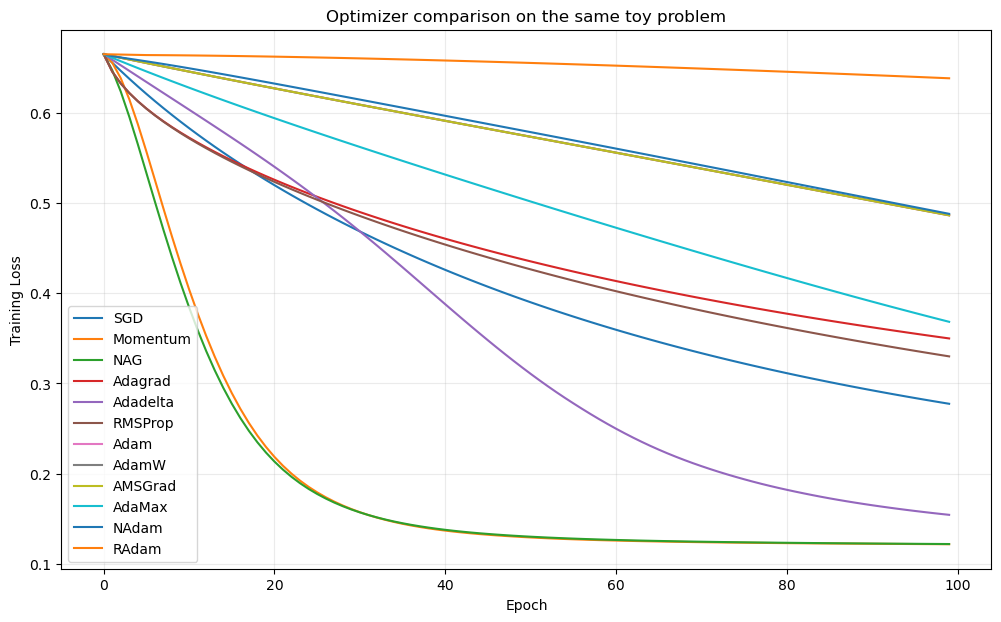

In [24]:
optimizers_to_compare = {
    "SGD": lambda p: torch.optim.SGD(p, lr=0.05),
    "Momentum": lambda p: torch.optim.SGD(p, lr=0.05, momentum=0.9),
    "NAG": lambda p: torch.optim.SGD(p, lr=0.05, momentum=0.9, nesterov=True),
    "Adagrad": lambda p: torch.optim.Adagrad(p, lr=0.01),
    "Adadelta": lambda p: torch.optim.Adadelta(p, lr=1.0),
    "RMSProp": lambda p: torch.optim.RMSprop(p, lr=0.001),
    "Adam": lambda p: torch.optim.Adam(p, lr=0.001),
    "AdamW": lambda p: torch.optim.AdamW(p, lr=0.001, weight_decay=0.01),
    "AMSGrad": lambda p: torch.optim.Adam(p, lr=0.001, amsgrad=True),
    "AdaMax": lambda p: torch.optim.Adamax(p, lr=0.002),
    "NAdam": lambda p: torch.optim.NAdam(p, lr=0.001),
    "RAdam": lambda p: torch.optim.RAdam(p, lr=0.001),
}

results = {}
for name, factory in optimizers_to_compare.items():
    _, loss_curve = train_model(factory, epochs=100)
    results[name] = loss_curve

plt.figure(figsize=(12, 7))
for name, curve in results.items():
    plt.plot(curve, label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer comparison on the same toy problem")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


## 26. Final differentiation table

| Optimizer | Main idea | Best-known use / situation | Main limitation |
|---|---|---|---|
| Batch GD | Full dataset gradient | Tiny datasets, learning fundamentals | Very slow on large data |
| SGD | Gradient descent with samples/batches | Strong baseline, classic DL | Needs LR tuning/schedules |
| Momentum | Adds velocity/history | Faster, less oscillation than SGD | Extra state |
| NAG | Look-ahead momentum | Momentum with correction | More complex |
| Adagrad | Per-parameter adaptive LR | Sparse gradients | LR can shrink too much |
| Adadelta | Moving adaptive statistics | Adaptive optimization without Adagrad's full accumulation | Less common today |
| RMSProp | Moving average of squared gradients | Adaptive learning, non-stationary problems | Hyperparameter sensitive |
| Adam | Momentum + adaptive LR | General-purpose deep learning | Can generalize differently from SGD |
| AdamW | Adam + decoupled weight decay | Transformers, modern DL | Still needs LR/WD tuning |
| AMSGrad | Adam with max second moment | Conservative Adam variant | Often little practical need |
| AdaMax | Adam using infinity norm | Adam-family experiments | Less common |
| Nadam | Adam + Nesterov | Adaptive + look-ahead momentum | Less common than AdamW |
| RAdam | Rectifies Adam's early variance | Adam variant / warm-up behavior | Less common |
| AdaBelief | Adapts to gradient prediction error | Research/experimentation | External implementation often needed |
| Yogi | Controls second-moment growth | Research / adaptive optimization | Less common |
| LARS | Layer-wise rate scaling | Large-batch training | More specialized |
| LAMB | Adam + layer-wise scaling | Large-batch Transformer training | Specialized |
| Adafactor | Factorized optimizer state | Very large Transformers / memory limits | More specialized tuning |
| Lion | Sign-based momentum | Modern research, large models | Requires careful LR tuning |
| Sophia | Approximate curvature | Large-model research | Research-oriented |
| Shampoo | Matrix preconditioning | Large-scale optimization research | More compute/memory complexity |
| Lookahead | Slow + fast weights | Stabilizing another optimizer | Meta-optimizer, not a standalone gradient rule |

### Easy memory trick

**SGD** → basic direction  
**Momentum** → remember direction  
**NAG** → look ahead  
**Adagrad** → adaptive per parameter  
**RMSProp** → adaptive squared-gradient average  
**Adam** → Momentum + RMSProp  
**AdamW** → Adam + decoupled weight decay  
**Adafactor** → save optimizer memory  
**LAMB/LARS** → layer-wise scaling  
**Lion** → sign-based update  
**Sophia/Shampoo** → curvature / preconditioning research

> **Practical starting point:** For a new deep-learning project, compare **AdamW and SGD+Momentum** rather than assuming one optimizer always wins. Tune learning rate, weight decay, batch size, and the learning-rate schedule together.


## 27. Common PyTorch optimizer workflow

Almost all standard PyTorch optimizers follow the same training pattern:

```python
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for X_batch, y_batch in dataloader:
    optimizer.zero_grad()

    prediction = model(X_batch)
    loss = criterion(prediction, y_batch)

    loss.backward()
    optimizer.step()
```

The optimizer does **not** calculate the loss. It uses gradients that were calculated by backpropagation.

### Learning-rate scheduler

An optimizer and scheduler are separate concepts:

```python
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=10, gamma=0.1
)

for epoch in range(30):
    # training loop
    ...
    scheduler.step()
```

So the complete training system is often:

**Model → Loss → Backpropagation → Optimizer → Learning-rate Scheduler → Repeat**
